# Abstract

This study is based on solar power prediction, where we will find the pattern between weather and ac power generation. In 1839, the ability of some materials to create an electrical charge from light was first observed by the French physicist Edmond Becquerel. Those were too inefficient for simple electric devices. Later on it was changed by hitting selenium. Based on this theory, in 1876, William Grylls Adams and Richard Evans Day published "The action of light on selenium 1876. Later on based on further development, instead of a single cell, we use multiple arrays of solar cells, which are used mostly in households and offices as a part of clean energy resources. This study focuses on the United Nations Sustainable Development Goal 7: Affordable and Clean Energy, addressing the global need for efficient and clean power sources. We know that there are a bunch of factors that affect the productivity of AC power for a solar panel which include irradiation, module temperature and ambient temperature. The global expansion of solar photovoltaics is central of achieving a sustainable energy transition, where governments are aiming to triple renewable energy capacity by 2030. Solar PV deployment is increasing in diverse climates beyond traditional mid-latitude regions, where environmental factors such as temperature, aerosols, and atmospheric conditions significantly influence energy output. Here, we will work on the Solar Power generation data from Kaggle to predict the impact of weather variables on solar power production, and we will optimize performance on our machine learning model. Key variables are solar irradiance variability, ambient temperature, and module temperature. As we will predict the power output so our model will be a regression model. By addressing environmental challenges, this research contributes to enhancing PV efficiency and advancement in global sustainable goals. 
   

# Dataset Collection

This data has been gathered at two solar power plants in India over a 34-day period. Each dataset has 2 pair of files, one is the power generation and another is the sensor reading dataset. Later on in the study, we will merge these 2 datasets and use this to perform prediction for solar power generation prediction. For collecting the sensor data, the data was gathered at a plant level, which was placed optimally. 
This dataset is kaggle gold standard, which means it is a very high quality and also the data was taken from either in real world application or from lab environment, not from simulation, also it avoids garbage in and garbage out problem.  

# Stakeholders and Audiences

This study finding will benefit mostly energy companies and also environmental organizations. The usage of machine learning algorithm has increased drastically in the power sectors. Like we will find so many examples that predicts wind power generation, grid based power production prediction. 
Also, these days a lot of companies are focusing on developing the goal of zero carbon emission like Apple , Microsoft, Toyota, Volkswagen. Developing a solar panel on the top of the factory is a modern approach. They can benefit from this study. This practice not only contributes to corporate environmental responsibility but also focuses global efforts to transition toward renewable energy and meet climate targets.  

Here are some factors that will benefit the Stakeholders : 

* Solar power forecasting will allow companies to plan energy storage and grid distribution, also it helps to reduce the waste and improve reliability
* Cost-effective solution as it helps to reduce the usage of heavy machines to predict power output
* If the prediction is reliable, it helps to support a decision on where to invest, based on the optimum temperature, sunlight we can create the solar plant in a perfect place for optimum output
* Data-driven insights strengthen campaigns for clean energy adoption
* Businesses can plan operations around predicted energy availability, reducing reliance on expensive non-renewable sources. 

# Research Questions

The research question of my interest
Data & environmental understanding
* RQ1: Which environmental factors most strongly influence solar power generation?
* RQ4: How does power generation vary across different timestamps?

Modelling approach & dataset design
* RQ3: Which regression model types are most suitable for this solar power dataset?
* RQ6: What train–validation–test split strategy is most appropriate for this time‑series solar dataset?
* RQ7: Which features can be removed without harming performance, and which features are most useful for prediction (feature importance/selection)?

Model performance & robustness
* RQ2: How accurately can the selected models predict solar power output on unseen data?
* RQ5: Can the chosen models reliably capture and track short‑term fluctuations in power generation at different timestamps?
* RQ9: Can the models accurately forecast solar power generation for the next few days to support grid management?

Operational insights & stakeholder value
* RQ8: How can predictive solar power generation models help stakeholders optimise energy planning and grid management?
* RQ10: Can the model outputs be used to identify when solar panels require cleaning or maintenance?
* RQ11: Can the models detect faulty or sub‑optimally performing equipment (e.g., underperforming inverters or strings)?

# Libraries

Before importing the libraries we need to make sure that those are already installed

In [9]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [10]:
!pip install torch
!pip install Optuna
!pip install xgboost

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
# For pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Util function

In [15]:
# Util
# In this section, we define reusable helper code for the project.
# Purpose of this function is to split train test based on unique dates
def split_and_scale_by_date(
    df,
    date_col="DATE",
    feature_cols=None,
    target_col="AC_POWER",
    split_ratio=0.8,
    random_state=42
):
    """
    Here, we will split the data frame into training and testing sets by unique dates and apply MinMax scaling.

    Returns: X_train, X_test, y_train, y_test, train_df, test_df, X_scaler, y_scaler
    """
    if feature_cols is None:
        raise ValueError("feature_cols must be provided as a list of column names.")

    # 1. Unique dates
    unique_dates = df[date_col].drop_duplicates().values

    # 2. Shuffle dates (reproducible)
    rng = np.random.RandomState(random_state)
    rng.shuffle(unique_dates)

    # 3. Split dates into train/test
    split_index = int(len(unique_dates) * split_ratio)
    train_dates = unique_dates[:split_index]
    test_dates = unique_dates[split_index:]

    # 4. Select rows for each set
    train_df = df[df[date_col].isin(train_dates)].copy()
    test_df = df[df[date_col].isin(test_dates)].copy()

    # 5. Initialize scalers
    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    # 6. Fit on training data only
    X_train = X_scaler.fit_transform(train_df[feature_cols])
    y_train = y_scaler.fit_transform(train_df[[target_col]])

    # 7. Transform test data
    X_test = X_scaler.transform(test_df[feature_cols])
    y_test = y_scaler.transform(test_df[[target_col]])

    return X_train, X_test, y_train, y_test, train_df, test_df, X_scaler, y_scaler


# Data Loading

## Ethical Consideration

When considering this dataset for prediction of Solar Power generation there are several factors that was considered. First the provacy and consent concern are minimal one of the reason is this is technical data also it does not contain any personal information. However there may be a chance of biasness for specific geography region. This dataset was developed from India for specific time not across the whole year. So country and season wise the condition may vary. The risk of potential misuse must be acknowledged, predictions should be applied to improve energy planning rather than exploitive purposes.
One thing to consider in here that the project focuses on one of the UN Sustainable Development Goal, which is the usage of renewable energy that reinforces the ethical foundation by promoting sustainability. 

## Data Loading Code

Here we have 2 csv file now for each plant data
1 : Plant Generation
2 : Plant Weather Sensor data

In [7]:
# Loading power generation data in df_power_generation and weather sensor data in df_weather_sensor
df_power_generation = pd.read_csv('Plant_Generation_Data.csv')
df_weather_sensor = pd.read_csv('Plant_Weather_Sensor_Data.csv')

In [12]:
# Now we will see the different data in here
# Loading power generation head
df_power_generation.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [13]:
# Loading weather sensor head
df_weather_sensor.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


## The Goal

As there are 2 different datasets at first we will analyze which data is necessary and which data is not required. We will also try to find missing values. If there are any missing values or duplicate values available we will clean the dataset. We may have to target merging the dataset and unify into one before processing into exploratory data analysis (EDA). 

## Dataset Cleaning and Preprocessing

In [16]:
# Here we will load power generation data from tail 
df_power_generation.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0
68777,17-06-2020 23:45,4135001,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0


In [17]:
# Here we will load weather sensor data from tail 
df_weather_sensor.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0
3181,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


From the power generation data frame we can say that multiple data was recorded for each time stamp. Now we will see how many datas are available in specific sample timestamp.

In [21]:
# Finding the unique number of values taken

df_power_generation['DATE_TIME'] = pd.to_datetime(
    df_power_generation['DATE_TIME'], format="%d-%m-%Y %H:%M"
)

# Filter date range
mask = (df_power_generation['DATE_TIME'] >= "2020-05-15") & \
       (df_power_generation['DATE_TIME'] <= "2020-06-17")

df_filtered = df_power_generation[mask]

# Group by DATE_TIME and count unique SOURCE_KEY
result = (
    df_filtered.groupby('DATE_TIME')['SOURCE_KEY']
    .nunique()
    .reset_index()
    .rename(columns={'SOURCE_KEY': 'unique_SOURCE_KEYs'})
)

result


,DATE_TIME,unique_SOURCE_KEYs
0,2020-05-15 00:00:00,21
1,2020-05-15 00:15:00,21
2,2020-05-15 00:30:00,21
3,2020-05-15 00:45:00,21
4,2020-05-15 01:00:00,22
...,...,...
3060,2020-06-16 23:00:00,22
3061,2020-06-16 23:15:00,22
3062,2020-06-16 23:30:00,22
3063,2020-06-16 23:45:00,22


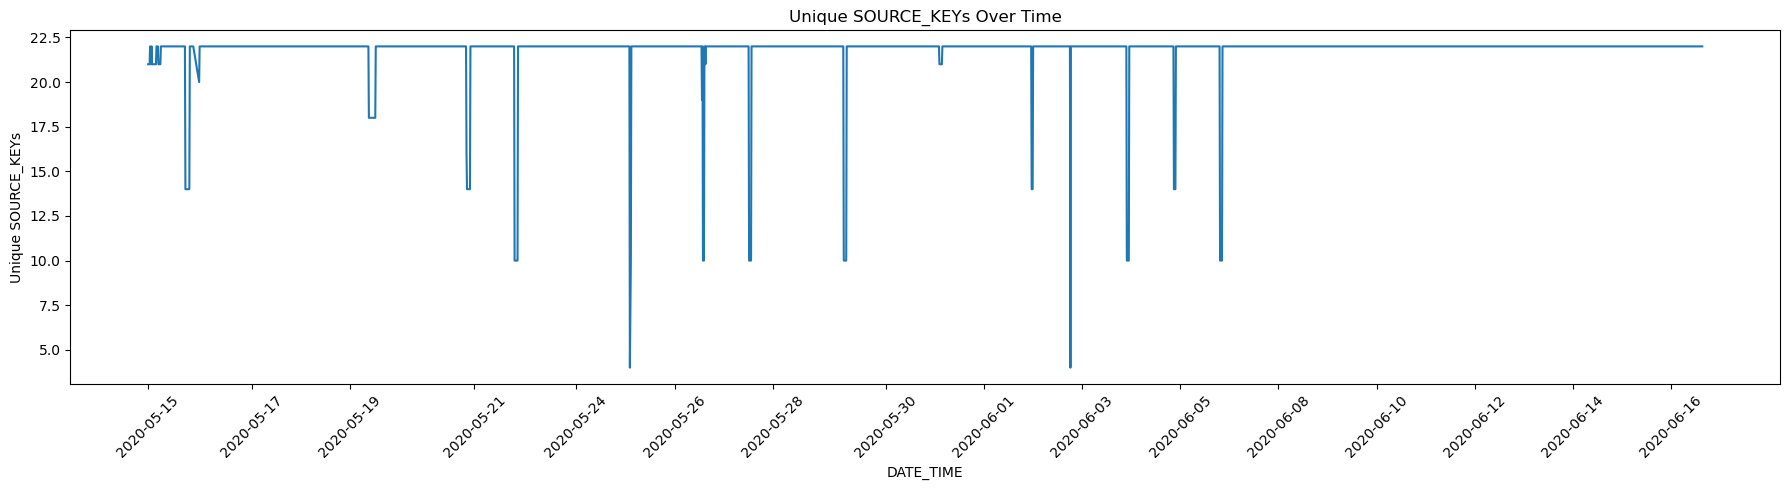

In [23]:
import matplotlib.pyplot as plt

# Ensure DATE_TIME is datetime
result['DATE_TIME'] = pd.to_datetime(result['DATE_TIME'])

plt.figure(figsize=(18,5))
plt.plot(result['DATE_TIME'], result['unique_SOURCE_KEYs'])

plt.xlabel("DATE_TIME")
plt.ylabel("Unique SOURCE_KEYs")
plt.title("Unique SOURCE_KEYs Over Time")

# Show only a few x-axis labels to avoid clutter
plt.xticks(result['DATE_TIME'][::200], rotation=45)

plt.tight_layout()
plt.show()


From the linechart we can see there is a variance of existence for unique timestamp numbers.
Now we will try to find the missing values

In [30]:
# Convert timestamps to datetime 
df_weather_sensor['DATE_TIME'] = pd.to_datetime(df_weather_sensor['DATE_TIME'],dayfirst=True)
df_power_generation['DATE_TIME'] = pd.to_datetime(df_power_generation['DATE_TIME'],dayfirst=True)

# Find timestamps that exist in weather but not in generation
missing_data = df_weather_sensor[~df_weather_sensor['DATE_TIME'].isin(df_power_generation['DATE_TIME'])]
print(f"Missing timestamp : ", len(missing_data))

Missing timestamp :  25


In [44]:
missing_data

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
542,2020-05-20 23:00:00,4135001,HmiyD2TTLFNqkNe,23.830852,21.024118,0.000000
543,2020-05-20 23:15:00,4135001,HmiyD2TTLFNqkNe,23.701162,20.786399,0.000000
544,2020-05-20 23:30:00,4135001,HmiyD2TTLFNqkNe,23.589626,20.572882,0.000000
545,2020-05-20 23:45:00,4135001,HmiyD2TTLFNqkNe,23.569009,20.622103,0.000000
546,2020-05-21 00:00:00,4135001,HmiyD2TTLFNqkNe,23.497382,20.584137,0.000000
547,2020-05-21 00:15:00,4135001,HmiyD2TTLFNqkNe,23.228943,20.230347,0.000000
548,2020-05-21 00:30:00,4135001,HmiyD2TTLFNqkNe,23.204518,20.179942,0.000000
731,2020-05-23 05:15:00,4135001,HmiyD2TTLFNqkNe,21.900024,20.994995,0.000000
919,2020-05-25 05:45:00,4135001,HmiyD2TTLFNqkNe,22.930503,21.104395,0.001908
1274,2020-05-28 22:30:00,4135001,HmiyD2TTLFNqkNe,21.259225,20.277036,0.000000


From the missing data we can see a pattern here irradiation is either 0 or so small nearby 0.

Now we will plot a graph to determine the Ac power generation distribution between day and night from the power generation dataframe

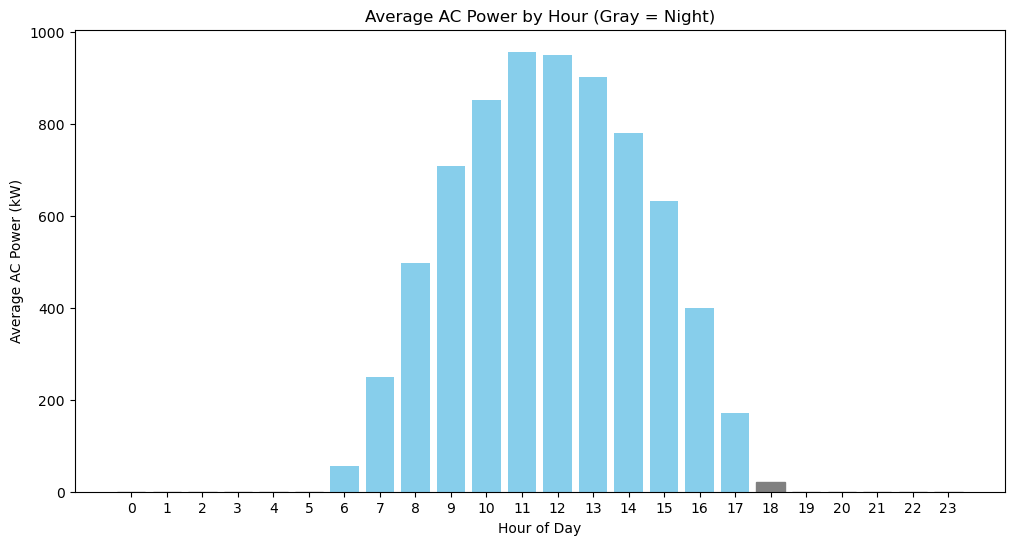

In [52]:
# Google colab help was taken in this part

import matplotlib.pyplot as plt
import pandas as pd

# Making sure DATE_TIME is datetime type
df_power_generation['DATE_TIME'] = pd.to_datetime(df_power_generation['DATE_TIME'], dayfirst=True)

# Extract hour from timestamp
df_power_generation['hour'] = df_power_generation['DATE_TIME'].dt.hour

# Compute average AC power per hour (or sum if you prefer)
hourly_ac_power = df_power_generation.groupby('hour')['AC_POWER'].mean()

# Defining night hours (6 PM to 6 AM)
night_hours = list(range(18, 24)) + list(range(0, 6))

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(hourly_ac_power.index, hourly_ac_power.values, color='skyblue')

# Highlight night hours in gray
for bar, hour in zip(bars, hourly_ac_power.index):
    if hour in night_hours:
        bar.set_color('gray')

plt.xlabel("Hour of Day")
plt.ylabel("Average AC Power (kW)")
plt.title("Average AC Power by Hour (Gray = Night)")
plt.xticks(range(0,24))
plt.show()


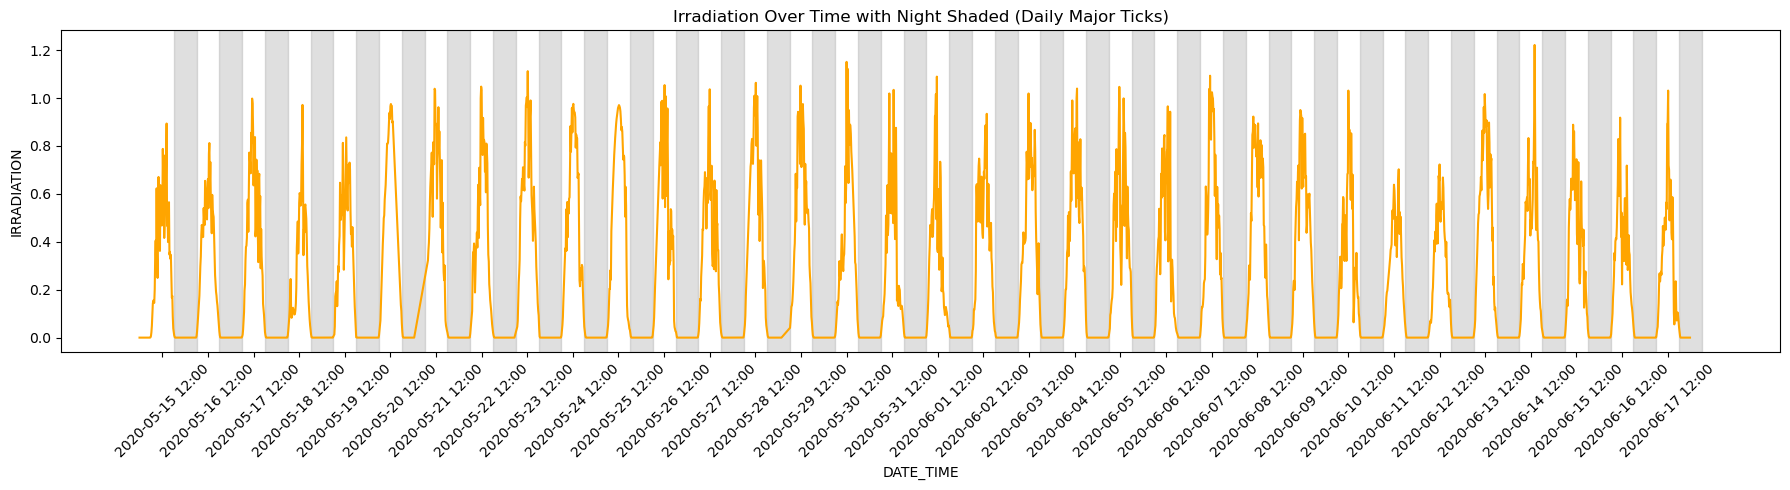

In [42]:
# Google colab help was taken to generate this graph

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure datetime
df_weather_sensor['DATE_TIME'] = pd.to_datetime(df_weather_sensor['DATE_TIME'])
df_weather_sensor = df_weather_sensor.sort_values('DATE_TIME')

fig, ax = plt.subplots(figsize=(18,5))

# Plot irradiation line
ax.plot(df_weather_sensor['DATE_TIME'], df_weather_sensor['IRRADIATION'], color='orange')

# --- Shade night (6 PM → 6 AM next day) ---
for day in df_weather_sensor['DATE_TIME'].dt.date.unique():
    night_start = pd.Timestamp(f"{day} 18:00:00")
    night_end   = night_start + pd.Timedelta(hours=12)
    ax.axvspan(night_start, night_end, alpha=0.25, color='gray')

# --- X-axis: one tick per day at 12:00 PM ---
daily_ticks = pd.date_range(start=df_weather_sensor['DATE_TIME'].min().date(),
                            end=df_weather_sensor['DATE_TIME'].max().date(),
                            freq='D') + pd.Timedelta(hours=12)

ax.set_xticks(daily_ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

plt.xticks(rotation=45)
plt.xlabel("DATE_TIME")
plt.ylabel("IRRADIATION")
plt.title("Irradiation Over Time")

plt.tight_layout()
plt.show()


In the graph of irradiation vs time for weather sensor data the gray area is night time where the irradiation is 0 mostly. 

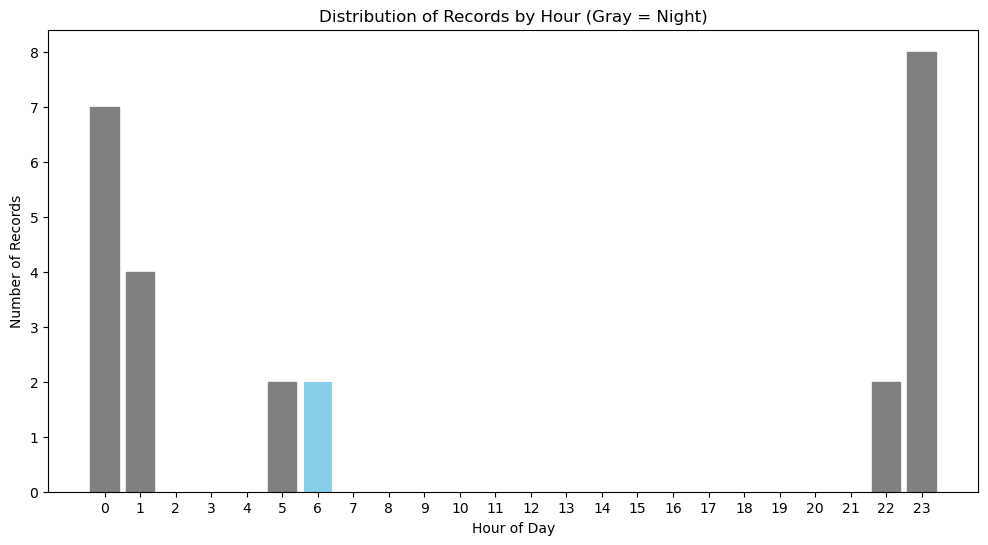

In [48]:
# Now we will plot a bar chart from the missing value to show the distribution of timestamp in either day or night

import matplotlib.pyplot as plt

# Extract hour from DATE_TIME
missing_data['hour'] = missing_data['DATE_TIME'].dt.hour

# Count records per hour
hour_counts = missing_data['hour'].value_counts().sort_index()

# Define night hours (6 PM to 6 AM)
night_hours = list(range(18, 24)) + list(range(0, 6))

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(hour_counts.index, hour_counts.values, color='skyblue')

# Highlight night hours
for bar, hour in zip(bars, hour_counts.index):
    if hour in night_hours:
        bar.set_color('gray')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Records")
plt.title("Distribution of Records by Hour (Gray = Night)")
plt.xticks(range(0,24))
plt.show()


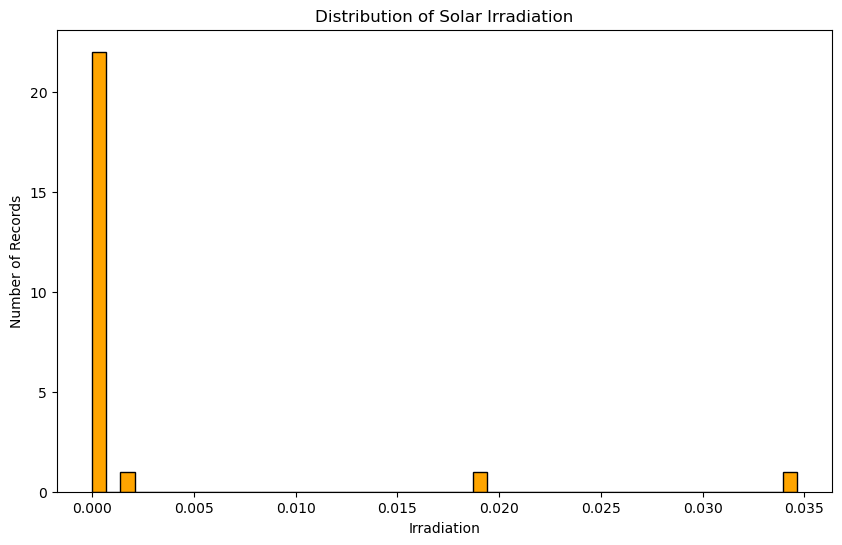

In [47]:
# This bar chart will show the irradiation distribution 

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(missing_data['IRRADIATION'], bins=50, color='orange', edgecolor='black')
plt.xlabel("Irradiation")
plt.ylabel("Number of Records")
plt.title("Distribution of Solar Irradiation")
plt.show()


The weather dataset has a fixed 15-minute interval. From the graph of irradiation vs temperature, we can say that irradiation is 0 at night time. For the missing value bar chart of the distribution of records by hour, it is clear that the missing value most of the time is associated with nighttime. And from the distribution of solar irradiation, it is also clear that most of the irradiation is 0. After finding the missing timestamps, we can say that they occur at night, with zero irradiation and no active inverters. From the AC Power generation distribution bar chart, we can see that the power generation is 0 when there is no irradiation. So it is safe to assume that power production is 0 for the missing values. 

## Steps for Handling Missing Values

For handling the missing values, here are the steps we will take

* We will group the generation data by timestamp and then sum the power from all inverters
* The weather data list of timestamps will be used to reindex the grouped result
* For a missing timestamp, the generated power will be filled with 0


This will ensure that the dataset is consistent and is ready to be merged, and zero values are explicitly represented


# References

Stats Stack Exchange (2017). What is the meaning of "gold data"? Available at: https://stats.stackexchange.com/questions/296828/what-is-the-meaning-of-gold-data (Accessed: 21 November 2025)

ScienceDirect (n.d.) Gold Standard Data. Available at: https://www.sciencedirect.com/topics/computer-science/gold-standard-data (Accessed: 21 November 2025)

Kaggle (n.d.) Solar Power Generation Data. Available at: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data (Accessed: 21 November 2025)

Solar Panel. Available at: https://en.wikipedia.org/wiki/Solar_panel (Accessed: 21 November 2025)

United Nations Sustainable Development Goal 7: Affordable and Clean Energy. Available at: https://globalgoals.org/goals/7-affordable-and-clean-energy/ (Accessed: 21 November 2025)

The environmental factors affecting solar photovoltaic output. Available at: https://www.sciencedirect.com/science/article/pii/S1364032124007998 (Accessed: 21 November 2025)

The top 10 manufacturing companies are committed to reducing their carbon footprint. Available at: https://manufacturing-today.com/news/top-ten-manufacturing-companies-committed-to-reducing-their-carbon-footprint/ (Accessed: 21 November 2025)

Util in a software project. Available at: https://stackoverflow.com/questions/3305511/is-it-good-to-have-utils-class-in-your-software-project (Accessed: 22 November 2025)